In [48]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np

In [51]:
# Get the images and labels
train_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1_imgs.npy')
train_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1_labels.npy')
val_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1_imgs.npy')
val_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1_labels.npy')
test_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1_imgs.npy')
test_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1_labels.npy')

In [52]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [53]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_labels))
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_labels))
test_ds = test_ds.batch(32)

In [54]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [55]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [56]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [57]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(256, 256, 1), name = 'image_input')
x = data_augmentation(image_input)
x = tf.keras.layers.Concatenate()([x, x, x])
x = preprocess_input(x) 

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs = image_input, outputs = outputs) # wrap all layers

In [58]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 256, 256,  │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 3)                │            │ sequential_3[0][… │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 256, 256)  │          0 │ concatenate_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 256, 256)  │          0 │ concatenate_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 256, 256)  │          0 │ concatenate_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 256, 256,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 256,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      2,049 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [59]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ]
)

In [60]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [61]:
initial_epochs = 20
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/20
245/247 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - auc_4: 0.5393 - loss: 0.6682

/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: auc_4,loss,val_auc_4,val_loss
  current = self.get_monitor_value(logs)
/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


247/247 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - auc_4: 0.5675 - loss: 0.6454 - val_auc_4: 0.6743 - val_loss: 0.5967
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - auc_4: 0.6183 - loss: 0.6176 - val_auc_4: 0.6853 - val_loss: 0.5904
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - auc_4: 0.6398 - loss: 0.6078 - val_auc_4: 0.6976 - val_loss: 0.5848
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - auc_4: 0.6601 - loss: 0.5939 - val_auc_4: 0.6988 - val_loss: 0.5829
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - auc_4: 0.6644 - loss: 0.5923 - val_auc_4: 0.7033 - val_loss: 0.5816
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - auc_4: 0.6681 - loss: 0.5913 - val_auc_4: 0.7087 - val_loss: 0.5766
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - auc_4: 0.6681 - loss: 0.5905 - val_auc_4: 0.7080 - val_loss: 0.5786
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - auc_4: 0.6610 - loss: 0.5953 - val_auc_4: 0.7094 - val_loss: 0.5761
Epoch 9/20
247/247 ━━

In [62]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [63]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [64]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 256, 256,  │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 3)                │            │ sequential_3[0][… │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 256, 256)  │          0 │ concatenate_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 256, 256)  │          0 │ concatenate_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 256, 256)  │          0 │ concatenate_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 256, 256,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 256,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      2,049 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,861 (90.00 MB)

 Trainable params: 16,952,577 (64.67 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

 Optimizer params: 4,100 (16.02 KB)

In [65]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ],
)

In [66]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds,
                         callbacks=callbacks)

Epoch 21/30
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - auc_5: 0.6610 - loss: 0.6338

/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: auc_5,loss,val_auc_5,val_loss
  current = self.get_monitor_value(logs)


247/247 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - auc_5: 0.6674 - loss: 0.6131 - val_auc_5: 0.7130 - val_loss: 0.5790
Epoch 22/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - auc_5: 0.6967 - loss: 0.5828 - val_auc_5: 0.7205 - val_loss: 0.5769
Epoch 23/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - auc_5: 0.7174 - loss: 0.5654 - val_auc_5: 0.7238 - val_loss: 0.5745
Epoch 24/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - auc_5: 0.7354 - loss: 0.5482 - val_auc_5: 0.7283 - val_loss: 0.5795
Epoch 25/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - auc_5: 0.7508 - loss: 0.5381 - val_auc_5: 0.7336 - val_loss: 0.5713
Epoch 26/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - auc_5: 0.7626 - loss: 0.5245 - val_auc_5: 0.7357 - val_loss: 0.5834
Epoch 27/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - auc_5: 0.7795 - loss: 0.5102 - val_auc_5: 0.7408 - val_loss: 0.5740
Epoch 28/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - auc_5: 0.7998 - loss: 0.4919 - val_auc_5: 0.7406 - val_loss: 0.5780
Epoch 29/30


In [67]:
# Evaluate model
model.evaluate(test_ds)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - auc_5: 0.7632 - loss: 0.6162


[0.616165041923523, 0.7631754279136658]

In [68]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step


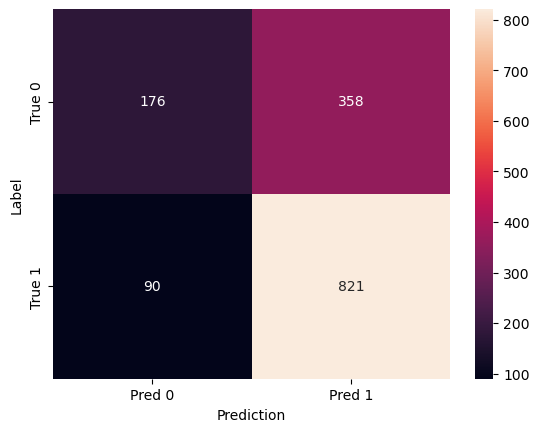

In [69]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

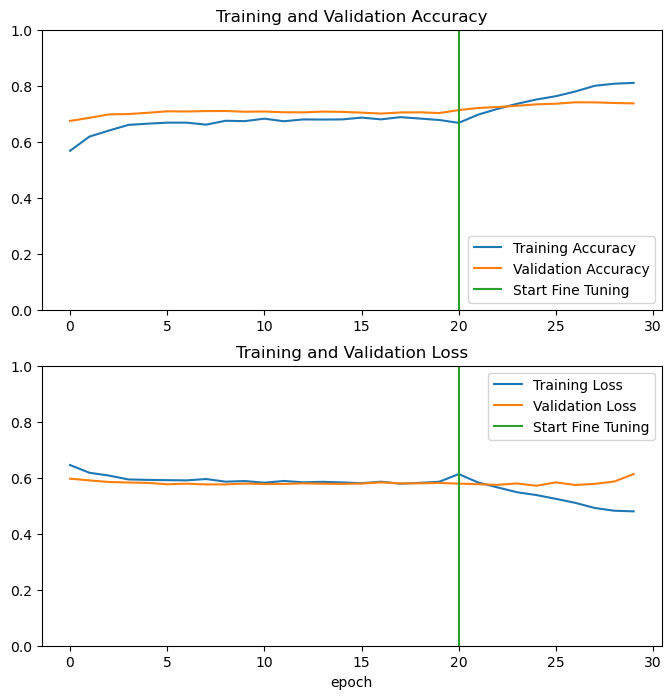

In [72]:
# Combine both for plotting
acc = history.history['auc_4'] + history_fine.history['auc_5']
val_acc = history.history['val_auc_4'] + history_fine.history['val_auc_5']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [71]:
print(history.history.keys())
print(history_fine.history.keys())

dict_keys(['auc_4', 'loss', 'val_auc_4', 'val_loss'])
dict_keys(['auc_5', 'loss', 'val_auc_5', 'val_loss'])
